## **Iterative workflow Usign Langgraph**

In [ ]:
#1. import the librabries 
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage,SystemMessage
import operator 
from dotenv import load_dotenv

In [4]:
load_dotenv()

True

In [ ]:
#2. setting different llm model to perform different tasks 

generator_llm= ChatOpenAI(model="gpt-4o-mini")
evaluator_llm = ChatOpenAI(model="gpt-4o")
optimizer_llm = ChatOpenAI(model="gpt-3.5-turbo")

In [32]:
# setting schema for evaluator llm 

from pydantic import BaseModel,Field
class TweetEvaluator(BaseModel):
    evaluation: Literal["approved","needs_improvement"] = Field(...,description="Final evaluation result")
    feedback:str =Field(...,description="Feedback for the tweet.")
    

In [33]:
# WE NEED STRUCTURE OUTPUT FORM THE LLLM HENCE
structured_llm_model = evaluator_llm.with_structured_output(TweetEvaluator)

In [59]:
#3. DEFINING THE STATE OF THE GRAPH 

class TweetState(TypedDict):

    topic: str
    tweet: str
    evaluation: Literal["approved","needs_improvement"]
    feedback:str
    iteration:int 
    max_iteration:int 


In [60]:
#5. building functions 

# generator function 
def generate_tweet(state:TweetState) -> TweetState:

    # prompt 
    message = [
       SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
            ]
    
    # invoke the generator model 
    response = generator_llm.invoke(message).content

    # return the response 
    return {"tweet":response,"tweet_history":[response]}


# evaluator function

def evaluate_tweet(state:TweetState) -> TweetState:

    # prompt 
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
                Evaluate the following tweet:

                Tweet: "{state['tweet']}"

                Use the criteria below to evaluate the tweet:

                1. Originality – Is this fresh, or have you seen it a hundred times before?  
                2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
                3. Punchiness – Is it short, sharp, and scroll-stopping?  
                4. Virality Potential – Would people retweet or share it?  
                5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

                Auto-reject if:
                - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
                - It exceeds 280 characters
                - It reads like a traditional setup-punchline joke
                - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

                ### Respond ONLY in structured format:
                - evaluation: "approved" or "needs_improvement"  
                - feedback: One paragraph explaining the strengths and weaknesses 
                """)
                ]
    
    # invoke the evaluator_llm 

    response = structured_llm_model.invoke(messages) 

    # return the response 

    return {"evaluation":response.evaluation,"feedback":response.feedback,"feedback_history":[response.feedback]}


# optimization function 

def optimize_tweet(state:TweetState) -> TweetState:

    #prompt 
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['tweet']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
            ]

    # invoke the model 
    response = optimizer_llm.invoke(messages).content
    iteration = state["iteration"] + 1

    return {'tweet': response, 'iteration': iteration, 'tweet_history': [response]}


In [66]:
# routing function 

def route_evaluation(state:TweetState):
    if state['evaluation']=='approved' or state['iteration']>=state['max_iteration']:
        return 'approved' 
    else:
        return 'need_improvement'

In [67]:
#4. state the graph 

graph = StateGraph(TweetState)

graph.add_node("generate",generate_tweet)
graph.add_node("evaluate",evaluate_tweet)
graph.add_node("optimize",optimize_tweet)

graph.add_edge(START,"generate")
graph.add_edge("generate","evaluate")
graph.add_conditional_edges("evaluate",route_evaluation,{'approved':END,'need_improvement':'optimize'})
graph.add_edge('optimize','evaluate')


In [68]:
workflow = graph.compile()


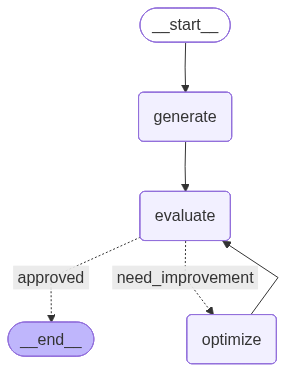

In [64]:
workflow

In [69]:
# testing 

initial_state = {
    "topic": "Indian Olampics",
    "iteration": 1,
    "max_iteration": 5
}
result = workflow.invoke(initial_state)

print(result)

{'topic': 'Indian Olampics', 'tweet': 'Forget the Olympics, the real "Olampics" are about surviving Indian train journeys: dodging luggage, mastering the art of sleeping standing up, and the intense competition for the last samosa. Gold medal goes to anyone who can find a charging point! 🥇🚂💼 #TrainOlympics', 'evaluation': 'approved', 'feedback': "The tweet excels in originality by playfully reimagining the Olympics as an everyday challenge tied to the uniquely chaotic experience of Indian train journeys. Its humor is tangible, eliciting a smile through relatable and exaggerated scenarios common to train travel, such as jostling for space and finding a charging point. It's concise and engaging, making it scroll-stopping. With its vivid imagery and relatable humor, the tweet has the potential to resonate with many users, enhancing its virality prospects. The format aligns well with Twitter norms, avoiding pitfalls like the question-answer format or setup-punchline, and it stays within th